This notebook contains the gathering of the data into a comprehensive dataset for Homework 1.

In [217]:
# Import the necessary libraries
import os
import tabulate
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import sportsdataverse as sdv
import polars as pl
from great_tables import GT, md
from adjustText import adjust_text
from scipy import stats

In [218]:
# Load up play by play data and game data for the 2021-2025 seasons
# from the sportsdataverse library
plays_df_polars = sdv.cfb.load_cfb_pbp(seasons=[2021, 2022, 2023, 2024, 2025], return_as_pandas=False)

# Convert the polar files to pandas dataframes
pbp_2021_2025_raw = plays_df_polars.to_pandas(use_pyarrow_extension_array=False)

In [219]:
# examine the shape of the play by play data
pbp_2021_2025_raw.shape

(778447, 477)

In [220]:
# Examine the available columns of the play by play data
col_list = pbp_2021_2025_raw.columns.tolist()
pd.set_option('display.max_seq_items', None)
print("\n".join(pbp_2021_2025_raw.columns))

season
game_id
game_play_number
pos_team_id
pos_team
def_pos_team_id
def_pos_team
pos_team_score
def_pos_team_score
half
period
down
distance
EPA
wpa
wp_before
wp_after
def_wp_before
def_wp_after
penalty_detail
yds_penalty
penalty_1st_conv
def_EPA
rz_play
scoring_opp
middle_8
stuffed_run
change_of_pos_team
downs_turnover
pos_score_diff_start
pos_score_pts
home_wp_before
away_wp_before
home_wp_after
away_wp_after
end_of_half
lead_pos_team
lead_play_type
lag_pos_team
orig_play_type
offense_score_play
defense_score_play
pos_score_diff
change_of_poss
rusher_player_name
yds_rushed
passer_player_name
receiver_player_name
yds_receiving
yds_sacked
sack_players
sack_player_name
sack_player_name2
pass_breakup_player_name
interception_player_name
yds_int_return
fumble_player_name
fumble_forced_player_name
fumble_recovered_player_name
yds_fumble_return
punter_player_name
yds_punted
yds_punt_return
yds_punt_gained
punt_block_player_name
punt_block_return_player_name
fg_kicker_player_name
yds_fg
fg_

In [221]:
# explore values of the orig_play_type column
pbp_2021_2025_raw['pass'].value_counts()

pass
False    484584
True     293863
Name: count, dtype: int64

In [222]:
# explore values of the seasonType column
pbp_2021_2025_raw['seasonType'].value_counts()

seasonType
2    739858
3     37573
4      1016
Name: count, dtype: int64

During the filtering process, I will filter out the following:

- Regular season only
- There is a valid possesion team (not na)
- The play type is a pass or a run
- epa is not null
- wpa is not null
- filter for only power 4 conferences (ACC, Big 12, Big 10, SEC)


Note: as seen above, the seasonType column has a few categories. 

According to the SportsDataVerse website: 

2 = regular season
3 = post season.

However, it does not say anything about 4. Since we will filter for 2, all 4's will be filtered out. I am quite sure that the rows with 4 are errors of some kind.

Here is the link I used to find this information:
https://py.sportsdataverse.org/docs/cfb/reference/loaders



NOTE:

It seems that this data does not include the conference of the school. 

To tackle this I will make a list of power 4 schools and filter out and possession team that is not in this list.

In [223]:
# create list of power 4 teams so that later we can filter out non power 4 teams from the play by play data
power4_teams = [
    'Nebraska Cornhuskers', 'Illinois Fighting Illini',
       'Minnesota Golden Gophers', 'Ohio State Buckeyes',
       'NC State Wolfpack', 'Tennessee Volunteers',
       'Virginia Tech Hokies', 'North Carolina Tar Heels',
       'Duke Blue Devils', 'Kansas Jayhawks', 'Michigan State Spartans',
       'Northwestern Wildcats', 'Alabama Crimson Tide',
       'Miami Hurricanes', 'Oklahoma Sooners', 'Georgia Bulldogs', 'Clemson Tigers', 'Texas A&M Aggies', 
       'Iowa State Cyclones', 'Penn State Nittany Lions',
       'Wisconsin Badgers', 'Florida Gators', 'Notre Dame Fighting Irish', 'Iowa Hawkeyes', 'Indiana Hoosiers', 'Texas Longhorns', 'Kentucky Wildcats',
       'Boston College Eagles', 'Michigan Wolverines', 'Rutgers Scarlet Knights', 'Stanford Cardinal', 'Kansas State Wildcats',
       'Maryland Terrapins', 'West Virginia Mountaineers',
       'Mississippi State Bulldogs', 'Missouri Tigers', 'Auburn Tigers', 'South Carolina Gamecocks',
       'Purdue Boilermakers', 'Houston Cougars', 'Texas Tech Red Raiders', 'Oklahoma State Cowboys', 'Baylor Bears',
       'Virginia Cavaliers', 'UCLA Bruins',
       'LSU Tigers', 'Florida State Seminoles', 'Ole Miss Rebels',
       'Louisville Cardinals', 'Oregon Ducks', 'Arkansas Razorbacks', 'Pittsburgh Panthers', 'Georgia Tech Yellow Jackets',
       'Wake Forest Demon Deacons', 'Syracuse Orange', 'Colorado Buffaloes', 'California Golden Bears', 'TCU Horned Frogs', 
       'Washington Huskies', 'Vanderbilt Commodores', 'UCF Knights', 'Cincinnati Bearcats', 'SMU Mustangs', 'BYU Cougars',
       'Utah Utes', 'Arizona State Sun Devils', 'Arizona Wildcats', 'USC Trojans'
       ]

In [224]:
# Filter the data to include only regular season plays,
# valid possession team,
# pass or run plays only,
# power 4 conferences only(ACC, Big 12, Big 10, SEC)
# and valid EPA and WPA values
pbp_filtered = pbp_2021_2025_raw[
    (pbp_2021_2025_raw['seasonType'] == 2) &
    (pbp_2021_2025_raw['pos_team'].notna()) &
    ((pbp_2021_2025_raw['pass'] == True) | (pbp_2021_2025_raw['rush'] == True)) &
    (pbp_2021_2025_raw['EPA'].notna()) &
    (pbp_2021_2025_raw['wpa'].notna()) &
    (pbp_2021_2025_raw['pos_team'].isin(power4_teams))
].copy()

Now, let's check up on the seasonType value to make sure.

In [225]:
# check the seasonType values in the filtered data
pbp_filtered['seasonType'].sort_values(ascending=False)

770205    2
1         2
2         2
3         2
4         2
         ..
22        2
21        2
20        2
19        2
18        2
Name: seasonType, Length: 271854, dtype: int64

In [226]:
# Check the shape of the filtered data
pbp_filtered.shape

(271854, 477)

In [227]:
# examine the available columns of the filtered play by play data
pbp_filtered.columns

Index(['season', 'game_id', 'game_play_number', 'pos_team_id', 'pos_team',
       'def_pos_team_id', 'def_pos_team', 'pos_team_score',
       'def_pos_team_score', 'half', 'period', 'down', 'distance', 'EPA',
       'wpa', 'wp_before', 'wp_after', 'def_wp_before', 'def_wp_after',
       'penalty_detail', 'yds_penalty', 'penalty_1st_conv', 'def_EPA',
       'rz_play', 'scoring_opp', 'middle_8', 'stuffed_run',
       'change_of_pos_team', 'downs_turnover', 'pos_score_diff_start',
       'pos_score_pts', 'home_wp_before', 'away_wp_before', 'home_wp_after',
       'away_wp_after', 'end_of_half', 'lead_pos_team', 'lead_play_type',
       'lag_pos_team', 'orig_play_type', 'offense_score_play',
       'defense_score_play', 'pos_score_diff', 'change_of_poss',
       'rusher_player_name', 'yds_rushed', 'passer_player_name',
       'receiver_player_name', 'yds_receiving', 'yds_sacked', 'sack_players',
       'sack_player_name', 'sack_player_name2', 'pass_breakup_player_name',
       'interceptio

Now, let's get rid of the columns we dont want.

Since we are only looking at offense, let's look keep only the following:
- 'pass'
- 'rush'
- 'EPA',
- 'wpa'
- 'yds_rushed'
- 'yds_receiving'
- 'pass_attempt'/ 'completion'
- 'statYardage'
- 'air_yards'
- 'yards_after_catch'
- 'new_down'
- 'adj_rush_yardage'
- 'line_yards'
- 'second_level_yards'
- 'open_field_yards'
- 'highlight_yards'
- 'EPA_rush'
- 'EPA_pass'
- 'EPA_scrimmage'
- 'drive_offense_plays'
- 'prog_drive_EPA'
- 'prog_drive_WPA'
- 'drive_offense_yards'
- 'pass_epa'
- 'rush_epa'
- 'EPA_success'

We will also need to keep attributes that identify the row and can be used for grouping/ aggregation.

The following columns will also be kept:
- 'season'
- 'week'
- 'pos_team'

In [228]:
# keep only necessary columns for analysis
pbp_final = pbp_filtered[['season', 'game_id', 'week', 'pos_team', 'pass', 'rush', 'EPA',
'wpa',
'yds_rushed',
'yds_receiving',
'pass_attempt',
'completion',
'statYardage',
'air_yards',
'yards_after_catch',
'new_down',
'adj_rush_yardage',
'line_yards',
'second_level_yards',
'open_field_yards',
'highlight_yards',
'EPA_rush',
'EPA_pass',
'EPA_scrimmage',
'drive_offense_plays',
'prog_drive_EPA',
'prog_drive_WPA',
'drive_offense_yards',
'pass_epa',
'rush_epa', 
'EPA_success',
'EPA_explosive']].copy()

---
_Note:_

The way I have this structured from here on out is as follows:

- Here, I aggregate all seasons data (2021-2025) and do the half vs half analysis.

- Then, below this section, I seperate out the individual seasons and compare their charts.


**Combined 2021 - 2025 analysis:**

In [229]:
# Aggregate the Weekly Offensive Metrics so that we can split season into equal halves in the next cell
weekly_offense = (
    pbp_final.groupby(['season','week', 'pos_team'])
    .apply(
        lambda x: pd.Series({
            'off_plays': len(x),
            'off_epa_per_play': x['EPA'].mean(),
            'off_pass_epa': x.loc[x['pass'] == 1, 'EPA'].mean(),
            'off_rush_epa': x.loc[x['rush'] == 1, 'EPA'].mean(),
            'off_wpa_per_play': x['wpa'].mean(),
            'off_pass_wpa': x.loc[x['pass'] == 1, 'wpa'].mean(),
            'off_rush_wpa': x.loc[x['rush'] == 1, 'wpa'].mean(),
            'off_success_rate': x['EPA_success'].mean(),
            'off_explosive_rate': x['EPA_explosive'].mean(),
            'pass_rate': (x['pass'] == 1).mean(),
            'complete_pass_pct': x['completion'].mean(),
            'yards_per_play': x['statYardage'].mean(),
            'adj_rush_yardage_per_play': x['adj_rush_yardage'].mean(),
            'air_yards_per_passing_play': x.loc[x['pass'] == 1, 'air_yards'].mean(),
            'yards_after_catch_per_passing_play': x.loc[x['pass'] == 1, 'yards_after_catch'].mean(),
            'new_down_per_play': x['new_down'].mean(),
            'oline_yards_per_rushing_play': x.loc[x['rush'] == 1, 'line_yards'].mean(),
            'second_line_yards_per_rushing_play': x['second_level_yards'].mean(),
            'open_field_yards_per_rushing_play': x['open_field_yards'].mean()
        }),
        include_groups=False
    )
    .reset_index()
)

In [230]:
# split the season into two havles for analysis
# create a column to define the half of the season based on the week number
weekly_offense['half_season'] = np.where(weekly_offense['week'] <= 9, "H1", "H2")

# Aggregate the Weekly Offensive Metrics by season, team, and half season
halfseason_team_panel = (
    weekly_offense.groupby(['pos_team', 'half_season'])
    .agg(
        mean_off_plays=('off_plays', 'mean'),
        mean_off_epa_per_play=('off_epa_per_play', 'mean'),
        mean_off_pass_epa=('off_pass_epa', 'mean'),
        mean_off_rush_epa=('off_rush_epa', 'mean'),
        mean_off_wpa_per_play=('off_wpa_per_play', 'mean'),
        mean_off_pass_wpa=('off_pass_wpa', 'mean'),
        mean_off_rush_wpa=('off_rush_wpa', 'mean'),
        mean_off_success_rate=('off_success_rate', 'mean'),
        mean_off_explosive_rate=('off_explosive_rate', 'mean'),
        mean_pass_rate=('pass_rate', 'mean'),
        mean_complete_pass_pct=('complete_pass_pct', 'mean'),
        mean_yards_per_play=('yards_per_play', 'mean'),
        mean_adj_rush_yardage_per_play=('adj_rush_yardage_per_play', 'mean'),
        mean_air_yards_per_passing_play=('air_yards_per_passing_play', 'mean'),
        mean_yards_after_catch_per_passing_play=('yards_after_catch_per_passing_play', 'mean'),
        mean_new_down_per_play=('new_down_per_play', 'mean'),
        mean_oline_yards_per_rushing_play=('oline_yards_per_rushing_play', 'mean'),
        mean_second_line_yards_per_rushing_play=('second_line_yards_per_rushing_play', 'mean'),
        mean_open_field_yards_per_rushing_play=('open_field_yards_per_rushing_play', 'mean')
    )
    .reset_index()
)

In [231]:
halfseason_team_panel

,pos_team,half_season,mean_off_plays,mean_off_epa_per_play,mean_off_pass_epa,mean_off_rush_epa,mean_off_wpa_per_play,mean_off_pass_wpa,mean_off_rush_wpa,mean_off_success_rate,...,mean_pass_rate,mean_complete_pass_pct,mean_yards_per_play,mean_adj_rush_yardage_per_play,mean_air_yards_per_passing_play,mean_yards_after_catch_per_passing_play,mean_new_down_per_play,mean_oline_yards_per_rushing_play,mean_second_line_yards_per_rushing_play,mean_open_field_yards_per_rushing_play
0,Alabama Crimson Tide,H1,66.900000,0.193011,0.274155,0.106231,0.001242,0.002331,0.000095,0.477748,...,0.492494,0.304404,6.709884,3.528826,NaN,NaN,1.776126,2.652141,0.584677,1.805594
1,Alabama Crimson Tide,H2,69.652174,0.152291,0.230622,0.065810,0.001814,0.003574,0.000209,0.482021,...,0.501338,0.296734,6.376313,3.484355,7.030711,5.653123,1.788732,2.633353,0.564195,1.350151
2,Arizona State Sun Devils,H1,67.083333,0.102155,0.064620,0.145424,0.002139,0.002318,0.002186,0.463695,...,0.499475,0.285039,6.158834,3.895798,6.600000,5.083333,1.813520,2.963282,0.634438,1.508549
3,Arizona State Sun Devils,H2,64.818182,0.090248,0.037562,0.149887,0.002677,0.002742,0.002186,0.449060,...,0.461834,0.260282,5.816014,4.020958,9.127593,6.594231,1.816976,3.086025,0.623765,1.609572
4,Arizona Wildcats,H1,67.564103,0.067027,0.048959,0.079075,0.002528,0.003923,0.000875,0.465850,...,0.570062,0.341390,6.314400,3.717198,NaN,NaN,1.785037,2.778780,0.630643,1.737319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,Washington Huskies,H2,64.380952,0.103173,0.084974,0.114512,0.003193,0.003675,0.001936,0.474891,...,0.548146,0.324542,6.085777,3.733313,8.296687,4.990278,1.798356,2.887593,0.560591,1.409525
132,West Virginia Mountaineers,H1,70.615385,0.064099,0.071251,0.047507,0.002044,0.002283,0.002178,0.445096,...,0.460701,0.264973,5.871576,3.519174,7.926829,4.607143,1.836455,2.690863,0.547287,1.442529
133,West Virginia Mountaineers,H2,68.850000,0.013860,-0.003155,-0.001068,0.001496,0.001865,0.001003,0.426174,...,0.459113,0.242237,5.624757,3.684307,8.482809,5.644160,1.861277,2.807282,0.589884,1.588501
134,Wisconsin Badgers,H1,65.179487,-0.018746,-0.082909,0.017617,0.000032,0.000335,-0.001013,0.443394,...,0.446080,0.246442,5.725952,3.664540,8.450000,5.000000,1.811305,2.860030,0.530993,1.294545


In [232]:
# check the value counts so that there are only 2 per team (one for each half of the season)
halfseason_team_panel['pos_team'].value_counts().sort_values(ascending=False)

pos_team
Alabama Crimson Tide          2
Arizona State Sun Devils      2
Arizona Wildcats              2
Arkansas Razorbacks           2
Auburn Tigers                 2
                             ..
Virginia Tech Hokies          2
Wake Forest Demon Deacons     2
Washington Huskies            2
West Virginia Mountaineers    2
Wisconsin Badgers             2
Name: count, Length: 68, dtype: int64

In [233]:
# Pivot to a wide format such that h1 vs h2 metrics can be compared for each team
metrics_wide = halfseason_team_panel.pivot(index='pos_team', columns='half_season')
metrics_wide.columns = [f"{val}_{stat}" for val, stat in metrics_wide.columns]
metrics_wide = metrics_wide.reset_index()

In [234]:
# Look at the metrics dataframe to confirm that the operations above worked as expected
metrics_wide

,pos_team,mean_off_plays_H1,mean_off_plays_H2,mean_off_epa_per_play_H1,mean_off_epa_per_play_H2,mean_off_pass_epa_H1,mean_off_pass_epa_H2,mean_off_rush_epa_H1,mean_off_rush_epa_H2,mean_off_wpa_per_play_H1,...,mean_yards_after_catch_per_passing_play_H1,mean_yards_after_catch_per_passing_play_H2,mean_new_down_per_play_H1,mean_new_down_per_play_H2,mean_oline_yards_per_rushing_play_H1,mean_oline_yards_per_rushing_play_H2,mean_second_line_yards_per_rushing_play_H1,mean_second_line_yards_per_rushing_play_H2,mean_open_field_yards_per_rushing_play_H1,mean_open_field_yards_per_rushing_play_H2
0,Alabama Crimson Tide,66.900000,69.652174,0.193011,0.152291,0.274155,0.230622,0.106231,0.065810,0.001242,...,NaN,5.653123,1.776126,1.788732,2.652141,2.633353,0.584677,0.564195,1.805594,1.350151
1,Arizona State Sun Devils,67.083333,64.818182,0.102155,0.090248,0.064620,0.037562,0.145424,0.149887,0.002139,...,5.083333,6.594231,1.813520,1.816976,2.963282,3.086025,0.634438,0.623765,1.508549,1.609572
2,Arizona Wildcats,67.564103,65.571429,0.067027,0.073549,0.048959,0.121567,0.079075,-0.019381,0.002528,...,NaN,3.538132,1.785037,1.824024,2.778780,2.695623,0.630643,0.582359,1.737319,1.901154
3,Arkansas Razorbacks,69.102564,66.750000,0.163451,0.031609,0.191175,0.046974,0.142196,0.025829,0.002589,...,9.000000,5.316845,1.772590,1.803893,2.889597,2.963838,0.676414,0.670553,1.948660,1.886001
4,Auburn Tigers,65.625000,66.300000,0.079028,0.058717,0.041257,-0.071262,0.103202,0.152876,-0.000723,...,4.153846,5.312418,1.804771,1.823823,2.806482,2.873982,0.654338,0.680870,1.934653,2.067355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,Virginia Tech Hokies,65.410256,60.947368,0.017051,-0.007349,0.033515,-0.072924,0.018073,0.047436,0.001152,...,-3.600000,4.983333,1.827746,1.835774,2.598146,3.063770,0.553266,0.671417,1.553180,1.880043
64,Wake Forest Demon Deacons,70.289474,71.619048,0.076496,0.077394,0.127115,0.067365,0.027336,0.052072,0.003107,...,4.111111,6.980399,1.792274,1.839157,2.705843,2.804452,0.518905,0.503442,1.369803,0.857097
65,Washington Huskies,66.375000,64.380952,0.195298,0.103173,0.307602,0.084974,0.054442,0.114512,0.001901,...,7.000000,4.990278,1.766131,1.798356,2.928872,2.887593,0.562547,0.560591,1.357671,1.409525
66,West Virginia Mountaineers,70.615385,68.850000,0.064099,0.013860,0.071251,-0.003155,0.047507,-0.001068,0.002044,...,4.607143,5.644160,1.836455,1.861277,2.690863,2.807282,0.547287,0.589884,1.442529,1.588501


In [235]:
# Create a list of metrics to analyze for the loop below
metric_list = [
    'mean_off_plays', 
       'mean_off_epa_per_play',
       'mean_off_pass_epa', 'mean_off_rush_epa', 'mean_off_wpa_per_play',
       'mean_off_pass_wpa',
       'mean_off_rush_wpa', 
       'mean_off_success_rate', 
       'mean_off_explosive_rate', 
       'mean_pass_rate', 'mean_complete_pass_pct',
       'mean_yards_per_play', 'mean_adj_rush_yardage_per_play',
       'mean_air_yards_per_passing_play',
       'mean_yards_after_catch_per_passing_play',
       'mean_new_down_per_play', 
       'mean_oline_yards_per_rushing_play',
       'mean_second_line_yards_per_rushing_play',
       'mean_open_field_yards_per_rushing_play'
]

# Compute Pearson r, p-value, and R-squared
corr_data = []

for m in metric_list:
    col_h1 = f"{m}_H1"
    col_h2 = f"{m}_H2"
    
    valid_data = metrics_wide[[col_h1, col_h2]].dropna()
    r, p_val = stats.pearsonr(valid_data[col_h1], valid_data[col_h2])
    
    corr_data.append({
        'metric': m,
        'r': r,
        'p_value': p_val,
        'r_squared': r ** 2
    })

correlation_results = pd.DataFrame(corr_data).sort_values(by='r', ascending=False)

In [236]:
# Create a formatted table using great_tables to display the correlation results
GT(correlation_results).tab_header(
    title="2021-2025 CFB Offense Split-Half Reliability",
    subtitle="Pearson Correlation (r) between Weeks 1-9 (H1) and Weeks 10-18 (H2)"
).cols_label(
    metric="Offensive Metric",
    r="Pearson r",
    p_value="p-value",
    r_squared="R²"
).fmt_number(
    columns=["r", "p_value", "r_squared"], 
    decimals=3
)

GT(_tbl_data=                                     metric         r       p_value  r_squared
9                            mean_pass_rate  0.828014  3.063264e-18   0.685608
10                   mean_complete_pass_pct  0.773774  1.026287e-14   0.598726
7                     mean_off_success_rate  0.747797  2.354021e-13   0.559200
1                     mean_off_epa_per_play  0.703308  2.269120e-11   0.494642
11                      mean_yards_per_play  0.682045  1.514830e-10   0.465185
17  mean_second_line_yards_per_rushing_play  0.681200  1.628145e-10   0.464034
0                            mean_off_plays  0.669478  4.325446e-10   0.448200
2                         mean_off_pass_epa  0.615541  2.322105e-08   0.378891
12           mean_adj_rush_yardage_per_play  0.599023  6.799289e-08   0.358829
15                   mean_new_down_per_play  0.593374  9.683783e-08   0.352093
3                         mean_off_rush_epa  0.577533  2.520143e-07   0.333545
16        mean_oline_yards_per_rushing_play  0.572555  3.368956e-07   0.327819
18   mean_open_field_yards_per_rushing_play  0.505397  1.103708e-05   0.255426
8                   mean_off_explosive_rate  0.434922  2.103472e-04   0.189157
4                     mean_off_wpa_per_play  0.375946  1.580805e-03   0.141336
6                         mean_off_rush_wpa  0.369117  1.951185e-03   0.136248
13          mean_air_yards_per_passing_play  0.350872  1.247997e-02   0.123111
5                         mean_off_pass_wpa  0.284337  1.877513e-02   0.080848
14  mean_yards_after_catch_per_passing_play  0.008866  9.512714e-01   0.000079, _body=<great_tables._gt_data.Body object at 0x000001D56D1BD820>, _boxhead=Boxhead([ColInfo(var='metric', type=<ColInfoTypeEnum.default: 1>, column_label='Offensive Metric', column_align='left', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001D56D1BFC20>, _spanners=Spanners([]), _heading=Heading(title='2021-2025 CFB Offense Split-Half Reliability', subtitle='Pearson Correlation (r) between Weeks 1-9 (H1) and Weeks 10-18 (H2)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001D443CC31D0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001D56D1BC170>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000001D56D1BEF60>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000001D57E0E3050>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(sc

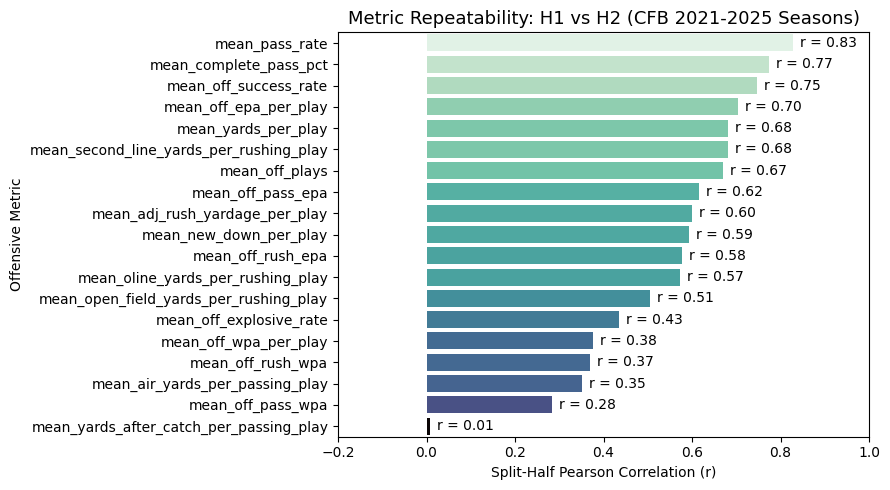

In [237]:
# Create a visualization of the results from the table above
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=correlation_results,
    x='r',
    y='metric',
    palette='mako',
    hue='r',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"r = {width:.2f}",
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10
    )

plt.xlim(-0.2, 1.0)
plt.title("Metric Repeatability: H1 vs H2 (CFB 2021-2025 Seasons)", fontsize=13)
plt.xlabel("Split-Half Pearson Correlation (r)")
plt.ylabel("Offensive Metric")
plt.tight_layout()
plt.show()

According to the comprehensive data from the 2021-2025 cfb seasons, the top 3 best offensive metrics were:
- 'mean_pass_rate', 
- 'mean_complete_pass_pct'
- 'mean_off_success_rate'

However, lets' compare individual years and compare them as well.

---
### **Seperate 2021 - 2025 analysis:**

## QUICK NOTE **Important**:

After further analysis, the following stats contain majority null values outside of the 2025 season:

- 'mean_air_yards_per_passing_play'
- 'mean_yards_after_catch_per_passing_play'

When used outside of the 2025 data, they would cause an error when trying to compute them. 

Therefore, they will be taken out of the analysis for the years 2021-2024 in the below analysis. However, it will be kept for the year 2025 to examine its impact when most of the values are not null.

This discovery may also give insight into why they have a very low r value in the above combined analysis bar chart. This point will be re-iterated and expanded upon in the conclusion.

In [238]:
# Create 5 seperate dataframes for each of the 5 seasons in the dataset to be used for further analysis
df_2021 = pbp_final[pbp_final['season'] == 2021].copy()
df_2022 = pbp_final[pbp_final['season'] == 2022].copy()
df_2023 = pbp_final[pbp_final['season'] == 2023].copy()
df_2024 = pbp_final[pbp_final['season'] == 2024].copy()
df_2025 = pbp_final[pbp_final['season'] == 2025].copy()

In [239]:
# Aggregate the Weekly Offensive Metrics for each season individually

# 2021:
weekly_offense_2021 = (
    df_2021.groupby(['week', 'pos_team'])
    .apply(
        lambda x: pd.Series({
            'off_plays': len(x),
            'off_epa_per_play': x['EPA'].mean(),
            'off_pass_epa': x.loc[x['pass'] == 1, 'EPA'].mean(),
            'off_rush_epa': x.loc[x['rush'] == 1, 'EPA'].mean(),
            'off_wpa_per_play': x['wpa'].mean(),
            'off_pass_wpa': x.loc[x['pass'] == 1, 'wpa'].mean(),
            'off_rush_wpa': x.loc[x['rush'] == 1, 'wpa'].mean(),
            'off_success_rate': x['EPA_success'].mean(),
            'off_explosive_rate': x['EPA_explosive'].mean(),
            'pass_rate': (x['pass'] == 1).mean(),
            'complete_pass_pct': x['completion'].mean(),
            'yards_per_play': x['statYardage'].mean(),
            'adj_rush_yardage_per_play': x['adj_rush_yardage'].mean(),
            'air_yards_per_passing_play': x.loc[x['pass'] == 1, 'air_yards'].mean(),
            'yards_after_catch_per_passing_play': x.loc[x['pass'] == 1, 'yards_after_catch'].mean(),
            'new_down_per_play': x['new_down'].mean(),
            'oline_yards_per_rushing_play': x.loc[x['rush'] == 1, 'line_yards'].mean(),
            'second_line_yards_per_rushing_play': x['second_level_yards'].mean(),
            'open_field_yards_per_rushing_play': x['open_field_yards'].mean()
        }),
        include_groups=False
    )
    .reset_index()
)

# 2022:
weekly_offense_2022 = (
    df_2022.groupby(['week', 'pos_team'])
    .apply(
        lambda x: pd.Series({
            'off_plays': len(x),
            'off_epa_per_play': x['EPA'].mean(),
            'off_pass_epa': x.loc[x['pass'] == 1, 'EPA'].mean(),
            'off_rush_epa': x.loc[x['rush'] == 1, 'EPA'].mean(),
            'off_wpa_per_play': x['wpa'].mean(),
            'off_pass_wpa': x.loc[x['pass'] == 1, 'wpa'].mean(),
            'off_rush_wpa': x.loc[x['rush'] == 1, 'wpa'].mean(),
            'off_success_rate': x['EPA_success'].mean(),
            'off_explosive_rate': x['EPA_explosive'].mean(),
            'pass_rate': (x['pass'] == 1).mean(),
            'complete_pass_pct': x['completion'].mean(),
            'yards_per_play': x['statYardage'].mean(),
            'adj_rush_yardage_per_play': x['adj_rush_yardage'].mean(),
            'air_yards_per_passing_play': x.loc[x['pass'] == 1, 'air_yards'].mean(),
            'yards_after_catch_per_passing_play': x.loc[x['pass'] == 1, 'yards_after_catch'].mean(),
            'new_down_per_play': x['new_down'].mean(),
            'oline_yards_per_rushing_play': x.loc[x['rush'] == 1, 'line_yards'].mean(),
            'second_line_yards_per_rushing_play': x['second_level_yards'].mean(),
            'open_field_yards_per_rushing_play': x['open_field_yards'].mean()
        }),
        include_groups=False
    )
    .reset_index()
)

# 2023:
weekly_offense_2023 = (
    df_2023.groupby(['week', 'pos_team'])
    .apply(
        lambda x: pd.Series({
            'off_plays': len(x),
            'off_epa_per_play': x['EPA'].mean(),
            'off_pass_epa': x.loc[x['pass'] == 1, 'EPA'].mean(),
            'off_rush_epa': x.loc[x['rush'] == 1, 'EPA'].mean(),
            'off_wpa_per_play': x['wpa'].mean(),
            'off_pass_wpa': x.loc[x['pass'] == 1, 'wpa'].mean(),
            'off_rush_wpa': x.loc[x['rush'] == 1, 'wpa'].mean(),
            'off_success_rate': x['EPA_success'].mean(),
            'off_explosive_rate': x['EPA_explosive'].mean(),
            'pass_rate': (x['pass'] == 1).mean(),
            'complete_pass_pct': x['completion'].mean(),
            'yards_per_play': x['statYardage'].mean(),
            'adj_rush_yardage_per_play': x['adj_rush_yardage'].mean(),
            'air_yards_per_passing_play': x.loc[x['pass'] == 1, 'air_yards'].mean(),
            'yards_after_catch_per_passing_play': x.loc[x['pass'] == 1, 'yards_after_catch'].mean(),
            'new_down_per_play': x['new_down'].mean(),
            'oline_yards_per_rushing_play': x.loc[x['rush'] == 1, 'line_yards'].mean(),
            'second_line_yards_per_rushing_play': x['second_level_yards'].mean(),
            'open_field_yards_per_rushing_play': x['open_field_yards'].mean()
        }),
        include_groups=False
    )
    .reset_index()
)

# 2024:
weekly_offense_2024 = (
    df_2024.groupby(['week', 'pos_team'])
    .apply(
        lambda x: pd.Series({
            'off_plays': len(x),
            'off_epa_per_play': x['EPA'].mean(),
            'off_pass_epa': x.loc[x['pass'] == 1, 'EPA'].mean(),
            'off_rush_epa': x.loc[x['rush'] == 1, 'EPA'].mean(),
            'off_wpa_per_play': x['wpa'].mean(),
            'off_pass_wpa': x.loc[x['pass'] == 1, 'wpa'].mean(),
            'off_rush_wpa': x.loc[x['rush'] == 1, 'wpa'].mean(),
            'off_success_rate': x['EPA_success'].mean(),
            'off_explosive_rate': x['EPA_explosive'].mean(),
            'pass_rate': (x['pass'] == 1).mean(),
            'complete_pass_pct': x['completion'].mean(),
            'yards_per_play': x['statYardage'].mean(),
            'adj_rush_yardage_per_play': x['adj_rush_yardage'].mean(),
            'air_yards_per_passing_play': x.loc[x['pass'] == 1, 'air_yards'].mean(),
            'yards_after_catch_per_passing_play': x.loc[x['pass'] == 1, 'yards_after_catch'].mean(),
            'new_down_per_play': x['new_down'].mean(),
            'oline_yards_per_rushing_play': x.loc[x['rush'] == 1, 'line_yards'].mean(),
            'second_line_yards_per_rushing_play': x['second_level_yards'].mean(),
            'open_field_yards_per_rushing_play': x['open_field_yards'].mean()
        }),
        include_groups=False
    )
    .reset_index()
)

# 2025:
weekly_offense_2025 = (
    df_2025.groupby(['week', 'pos_team'])
    .apply(
        lambda x: pd.Series({
            'off_plays': len(x),
            'off_epa_per_play': x['EPA'].mean(),
            'off_pass_epa': x.loc[x['pass'] == 1, 'EPA'].mean(),
            'off_rush_epa': x.loc[x['rush'] == 1, 'EPA'].mean(),
            'off_wpa_per_play': x['wpa'].mean(),
            'off_pass_wpa': x.loc[x['pass'] == 1, 'wpa'].mean(),
            'off_rush_wpa': x.loc[x['rush'] == 1, 'wpa'].mean(),
            'off_success_rate': x['EPA_success'].mean(),
            'off_explosive_rate': x['EPA_explosive'].mean(),
            'pass_rate': (x['pass'] == 1).mean(),
            'complete_pass_pct': x['completion'].mean(),
            'yards_per_play': x['statYardage'].mean(),
            'adj_rush_yardage_per_play': x['adj_rush_yardage'].mean(),
            'air_yards_per_passing_play': x.loc[x['pass'] == 1, 'air_yards'].mean(),
            'yards_after_catch_per_passing_play': x.loc[x['pass'] == 1, 'yards_after_catch'].mean(),
            'new_down_per_play': x['new_down'].mean(),
            'oline_yards_per_rushing_play': x.loc[x['rush'] == 1, 'line_yards'].mean(),
            'second_line_yards_per_rushing_play': x['second_level_yards'].mean(),
            'open_field_yards_per_rushing_play': x['open_field_yards'].mean()
        }),
        include_groups=False
    )
    .reset_index()
)

In [240]:
# Create a column to define the half of the season based on the week number for 201-2025
weekly_offense_2021['half_season'] = np.where(weekly_offense_2021['week'] <= 9, "H1", "H2")
weekly_offense_2022['half_season'] = np.where(weekly_offense_2022['week'] <= 9, "H1", "H2")
weekly_offense_2023['half_season'] = np.where(weekly_offense_2023['week'] <= 9, "H1", "H2")
weekly_offense_2024['half_season'] = np.where(weekly_offense_2024['week'] <= 9, "H1", "H2")
weekly_offense_2025['half_season'] = np.where(weekly_offense_2025['week'] <= 9, "H1", "H2")

# Aggregate the Weekly Offensive Metrics by season, team, and half season

# 2021:
halfseason_team_panel_2021 = (
    weekly_offense_2021.groupby(['pos_team', 'half_season'])
    .agg(
        mean_off_plays=('off_plays', 'mean'),
        mean_off_epa_per_play=('off_epa_per_play', 'mean'),
        mean_off_pass_epa=('off_pass_epa', 'mean'),
        mean_off_rush_epa=('off_rush_epa', 'mean'),
        mean_off_wpa_per_play=('off_wpa_per_play', 'mean'),
        mean_off_pass_wpa=('off_pass_wpa', 'mean'),
        mean_off_rush_wpa=('off_rush_wpa', 'mean'),
        mean_off_success_rate=('off_success_rate', 'mean'),
        mean_off_explosive_rate=('off_explosive_rate', 'mean'),
        mean_pass_rate=('pass_rate', 'mean'),
        mean_complete_pass_pct=('complete_pass_pct', 'mean'),
        mean_yards_per_play=('yards_per_play', 'mean'),
        mean_adj_rush_yardage_per_play=('adj_rush_yardage_per_play', 'mean'),
        mean_air_yards_per_passing_play=('air_yards_per_passing_play', 'mean'),
        mean_yards_after_catch_per_passing_play=('yards_after_catch_per_passing_play', 'mean'),
        mean_new_down_per_play=('new_down_per_play', 'mean'),
        mean_oline_yards_per_rushing_play=('oline_yards_per_rushing_play', 'mean'),
        mean_second_line_yards_per_rushing_play=('second_line_yards_per_rushing_play', 'mean'),
        mean_open_field_yards_per_rushing_play=('open_field_yards_per_rushing_play', 'mean')
    )
    .reset_index()
)

# 2022:
halfseason_team_panel_2022 = (
    weekly_offense_2022.groupby(['pos_team', 'half_season'])
    .agg(
        mean_off_plays=('off_plays', 'mean'),
        mean_off_epa_per_play=('off_epa_per_play', 'mean'),
        mean_off_pass_epa=('off_pass_epa', 'mean'),
        mean_off_rush_epa=('off_rush_epa', 'mean'),
        mean_off_wpa_per_play=('off_wpa_per_play', 'mean'),
        mean_off_pass_wpa=('off_pass_wpa', 'mean'),
        mean_off_rush_wpa=('off_rush_wpa', 'mean'),
        mean_off_success_rate=('off_success_rate', 'mean'),
        mean_off_explosive_rate=('off_explosive_rate', 'mean'),
        mean_pass_rate=('pass_rate', 'mean'),
        mean_complete_pass_pct=('complete_pass_pct', 'mean'),
        mean_yards_per_play=('yards_per_play', 'mean'),
        mean_adj_rush_yardage_per_play=('adj_rush_yardage_per_play', 'mean'),
        mean_air_yards_per_passing_play=('air_yards_per_passing_play', 'mean'),
        mean_yards_after_catch_per_passing_play=('yards_after_catch_per_passing_play', 'mean'),
        mean_new_down_per_play=('new_down_per_play', 'mean'),
        mean_oline_yards_per_rushing_play=('oline_yards_per_rushing_play', 'mean'),
        mean_second_line_yards_per_rushing_play=('second_line_yards_per_rushing_play', 'mean'),
        mean_open_field_yards_per_rushing_play=('open_field_yards_per_rushing_play', 'mean')
    )
    .reset_index()
)

# 2023:
halfseason_team_panel_2023 = (
    weekly_offense_2023.groupby(['pos_team', 'half_season'])
    .agg(
        mean_off_plays=('off_plays', 'mean'),
        mean_off_epa_per_play=('off_epa_per_play', 'mean'),
        mean_off_pass_epa=('off_pass_epa', 'mean'),
        mean_off_rush_epa=('off_rush_epa', 'mean'),
        mean_off_wpa_per_play=('off_wpa_per_play', 'mean'),
        mean_off_pass_wpa=('off_pass_wpa', 'mean'),
        mean_off_rush_wpa=('off_rush_wpa', 'mean'),
        mean_off_success_rate=('off_success_rate', 'mean'),
        mean_off_explosive_rate=('off_explosive_rate', 'mean'),
        mean_pass_rate=('pass_rate', 'mean'),
        mean_complete_pass_pct=('complete_pass_pct', 'mean'),
        mean_yards_per_play=('yards_per_play', 'mean'),
        mean_adj_rush_yardage_per_play=('adj_rush_yardage_per_play', 'mean'),
        mean_air_yards_per_passing_play=('air_yards_per_passing_play', 'mean'),
        mean_yards_after_catch_per_passing_play=('yards_after_catch_per_passing_play', 'mean'),
        mean_new_down_per_play=('new_down_per_play', 'mean'),
        mean_oline_yards_per_rushing_play=('oline_yards_per_rushing_play', 'mean'),
        mean_second_line_yards_per_rushing_play=('second_line_yards_per_rushing_play', 'mean'),
        mean_open_field_yards_per_rushing_play=('open_field_yards_per_rushing_play', 'mean')
    )
    .reset_index()
)

# 2024:
halfseason_team_panel_2024 = (
    weekly_offense_2024.groupby(['pos_team', 'half_season'])
    .agg(
        mean_off_plays=('off_plays', 'mean'),
        mean_off_epa_per_play=('off_epa_per_play', 'mean'),
        mean_off_pass_epa=('off_pass_epa', 'mean'),
        mean_off_rush_epa=('off_rush_epa', 'mean'),
        mean_off_wpa_per_play=('off_wpa_per_play', 'mean'),
        mean_off_pass_wpa=('off_pass_wpa', 'mean'),
        mean_off_rush_wpa=('off_rush_wpa', 'mean'),
        mean_off_success_rate=('off_success_rate', 'mean'),
        mean_off_explosive_rate=('off_explosive_rate', 'mean'),
        mean_pass_rate=('pass_rate', 'mean'),
        mean_complete_pass_pct=('complete_pass_pct', 'mean'),
        mean_yards_per_play=('yards_per_play', 'mean'),
        mean_adj_rush_yardage_per_play=('adj_rush_yardage_per_play', 'mean'),
        mean_air_yards_per_passing_play=('air_yards_per_passing_play', 'mean'),
        mean_yards_after_catch_per_passing_play=('yards_after_catch_per_passing_play', 'mean'),
        mean_new_down_per_play=('new_down_per_play', 'mean'),
        mean_oline_yards_per_rushing_play=('oline_yards_per_rushing_play', 'mean'),
        mean_second_line_yards_per_rushing_play=('second_line_yards_per_rushing_play', 'mean'),
        mean_open_field_yards_per_rushing_play=('open_field_yards_per_rushing_play', 'mean')
    )
    .reset_index()
)

# 2025:
halfseason_team_panel_2025 = (
    weekly_offense_2025.groupby(['pos_team', 'half_season'])
    .agg(
        mean_off_plays=('off_plays', 'mean'),
        mean_off_epa_per_play=('off_epa_per_play', 'mean'),
        mean_off_pass_epa=('off_pass_epa', 'mean'),
        mean_off_rush_epa=('off_rush_epa', 'mean'),
        mean_off_wpa_per_play=('off_wpa_per_play', 'mean'),
        mean_off_pass_wpa=('off_pass_wpa', 'mean'),
        mean_off_rush_wpa=('off_rush_wpa', 'mean'),
        mean_off_success_rate=('off_success_rate', 'mean'),
        mean_off_explosive_rate=('off_explosive_rate', 'mean'),
        mean_pass_rate=('pass_rate', 'mean'),
        mean_complete_pass_pct=('complete_pass_pct', 'mean'),
        mean_yards_per_play=('yards_per_play', 'mean'),
        mean_adj_rush_yardage_per_play=('adj_rush_yardage_per_play', 'mean'),
        mean_air_yards_per_passing_play=('air_yards_per_passing_play', 'mean'),
        mean_yards_after_catch_per_passing_play=('yards_after_catch_per_passing_play', 'mean'),
        mean_new_down_per_play=('new_down_per_play', 'mean'),
        mean_oline_yards_per_rushing_play=('oline_yards_per_rushing_play', 'mean'),
        mean_second_line_yards_per_rushing_play=('second_line_yards_per_rushing_play', 'mean'),
        mean_open_field_yards_per_rushing_play=('open_field_yards_per_rushing_play', 'mean')
    )
    .reset_index()
)

In [241]:
# Pivot to a wide format such that h1 vs h2 metrics can be compared for each team

# 2021:
metrics_wide_2021 = halfseason_team_panel_2021.pivot(index='pos_team', columns='half_season')
metrics_wide_2021.columns = [f"{val}_{stat}" for val, stat in metrics_wide_2021.columns]
metrics_wide_2021 = metrics_wide_2021.reset_index()

# 2022:
metrics_wide_2022 = halfseason_team_panel_2022.pivot(index='pos_team', columns='half_season')
metrics_wide_2022.columns = [f"{val}_{stat}" for val, stat in metrics_wide_2022.columns]
metrics_wide_2022 = metrics_wide_2022.reset_index()

# 2023:
metrics_wide_2023 = halfseason_team_panel_2023.pivot(index='pos_team', columns='half_season')
metrics_wide_2023.columns = [f"{val}_{stat}" for val, stat in metrics_wide_2023.columns]
metrics_wide_2023 = metrics_wide_2023.reset_index()

# 2024:
metrics_wide_2024 = halfseason_team_panel_2024.pivot(index='pos_team', columns='half_season')
metrics_wide_2024.columns = [f"{val}_{stat}" for val, stat in metrics_wide_2024.columns]
metrics_wide_2024 = metrics_wide_2024.reset_index()

# 2025:
metrics_wide_2025 = halfseason_team_panel_2025.pivot(index='pos_team', columns='half_season')
metrics_wide_2025.columns = [f"{val}_{stat}" for val, stat in metrics_wide_2025.columns]
metrics_wide_2025 = metrics_wide_2025.reset_index()

In [242]:
# Create a list of metrics to analyze for the loop below
metric_list = [
    'mean_off_plays', 
       'mean_off_epa_per_play',
       'mean_off_pass_epa', 'mean_off_rush_epa', 'mean_off_wpa_per_play',
       'mean_off_pass_wpa',
       'mean_off_rush_wpa', 
       'mean_off_success_rate', 
       'mean_off_explosive_rate', 
       'mean_pass_rate', 'mean_complete_pass_pct',
       'mean_yards_per_play', 'mean_adj_rush_yardage_per_play',
       'mean_new_down_per_play', 
       'mean_oline_yards_per_rushing_play',
       'mean_second_line_yards_per_rushing_play',
       'mean_open_field_yards_per_rushing_play'
]

# Compute Pearson r, p-value, and R-squared

#2021:
corr_data_2021 = []

for m in metric_list:
    col_h1 = f"{m}_H1"
    col_h2 = f"{m}_H2"
    
    valid_data = metrics_wide_2021[[col_h1, col_h2]].dropna()
    r, p_val = stats.pearsonr(valid_data[col_h1], valid_data[col_h2])
    
    corr_data_2021.append({
        'metric': m,
        'r': r,
        'p_value': p_val,
        'r_squared': r ** 2
    })

correlation_results_2021 = pd.DataFrame(corr_data_2021).sort_values(by='r', ascending=False)

#2022:
corr_data_2022 = []

for m in metric_list:
    col_h1 = f"{m}_H1"
    col_h2 = f"{m}_H2"
    
    valid_data = metrics_wide_2022[[col_h1, col_h2]].dropna()
    r, p_val = stats.pearsonr(valid_data[col_h1], valid_data[col_h2])
    
    corr_data_2022.append({
        'metric': m,
        'r': r,
        'p_value': p_val,
        'r_squared': r ** 2
    })

correlation_results_2022 = pd.DataFrame(corr_data_2022).sort_values(by='r', ascending=False)

#2023:
corr_data_2023 = []

for m in metric_list:
    col_h1 = f"{m}_H1"
    col_h2 = f"{m}_H2"
    
    valid_data = metrics_wide_2023[[col_h1, col_h2]].dropna()
    r, p_val = stats.pearsonr(valid_data[col_h1], valid_data[col_h2])
    
    corr_data_2023.append({
        'metric': m,
        'r': r,
        'p_value': p_val,
        'r_squared': r ** 2
    })

correlation_results_2023 = pd.DataFrame(corr_data_2023).sort_values(by='r', ascending=False)

#2024:
corr_data_2024 = []

for m in metric_list:
    col_h1 = f"{m}_H1"
    col_h2 = f"{m}_H2"
    
    valid_data = metrics_wide_2024[[col_h1, col_h2]].dropna()
    r, p_val = stats.pearsonr(valid_data[col_h1], valid_data[col_h2])
    
    corr_data_2024.append({
        'metric': m,
        'r': r,
        'p_value': p_val,
        'r_squared': r ** 2
    })

correlation_results_2024 = pd.DataFrame(corr_data_2024).sort_values(by='r', ascending=False)

# Create a new list that includes 'mean_air_yards_per_passing_play' and 'mean_yards_after_catch_per_passing_play' for the 2025 season.
metric_list = [
    'mean_off_plays', 
       'mean_off_epa_per_play',
       'mean_off_pass_epa', 'mean_off_rush_epa', 'mean_off_wpa_per_play',
       'mean_off_pass_wpa',
       'mean_off_rush_wpa', 
       'mean_off_success_rate', 
       'mean_off_explosive_rate', 
       'mean_pass_rate', 'mean_complete_pass_pct',
       'mean_yards_per_play', 'mean_adj_rush_yardage_per_play',
       'mean_air_yards_per_passing_play',
       'mean_yards_after_catch_per_passing_play',
       'mean_new_down_per_play', 
       'mean_oline_yards_per_rushing_play',
       'mean_second_line_yards_per_rushing_play',
       'mean_open_field_yards_per_rushing_play'
]

#2025:
corr_data_2025 = []

for m in metric_list:
    col_h1 = f"{m}_H1"
    col_h2 = f"{m}_H2"
    
    valid_data = metrics_wide_2025[[col_h1, col_h2]].dropna()
    r, p_val = stats.pearsonr(valid_data[col_h1], valid_data[col_h2])
    
    corr_data_2025.append({
        'metric': m,
        'r': r,
        'p_value': p_val,
        'r_squared': r ** 2
    })

correlation_results_2025 = pd.DataFrame(corr_data_2025).sort_values(by='r', ascending=False)

## 2021 table and visual:

In [243]:
# Create a formatted table using great_tables to display the correlation results
GT(correlation_results_2021).tab_header(
    title="2021 CFB Offense Split-Half Reliability",
    subtitle="Pearson Correlation (r) between Weeks 1-9 (H1) and Weeks 10-18 (H2)"
).cols_label(
    metric="Offensive Metric",
    r="Pearson r",
    p_value="p-value",
    r_squared="R²"
).fmt_number(
    columns=["r", "p_value", "r_squared"], 
    decimals=3
)

GT(_tbl_data=                                     metric         r       p_value  r_squared
9                            mean_pass_rate  0.659154  9.869027e-10   0.434483
10                   mean_complete_pass_pct  0.648255  2.278677e-09   0.420235
7                     mean_off_success_rate  0.517047  6.350021e-06   0.267337
13                   mean_new_down_per_play  0.432231  2.325329e-04   0.186824
15  mean_second_line_yards_per_rushing_play  0.423046  3.254154e-04   0.178968
0                            mean_off_plays  0.370926  1.846195e-03   0.137586
16   mean_open_field_yards_per_rushing_play  0.367136  2.072313e-03   0.134789
3                         mean_off_rush_epa  0.348069  3.630762e-03   0.121152
12           mean_adj_rush_yardage_per_play  0.330324  5.939534e-03   0.109114
1                     mean_off_epa_per_play  0.326048  6.659729e-03   0.106308
11                      mean_yards_per_play  0.321714  7.467038e-03   0.103500
14        mean_oline_yards_per_rushing_play  0.286448  1.787600e-02   0.082053
2                         mean_off_pass_epa  0.266231  2.820204e-02   0.070879
6                         mean_off_rush_wpa  0.096606  4.332169e-01   0.009333
8                   mean_off_explosive_rate  0.094771  4.420440e-01   0.008982
4                     mean_off_wpa_per_play -0.002651  9.828856e-01   0.000007
5                         mean_off_pass_wpa -0.022564  8.550766e-01   0.000509, _body=<great_tables._gt_data.Body object at 0x000001D43F3B62A0>, _boxhead=Boxhead([ColInfo(var='metric', type=<ColInfoTypeEnum.default: 1>, column_label='Offensive Metric', column_align='left', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001D5AF0252B0>, _spanners=Spanners([]), _heading=Heading(title='2021 CFB Offense Split-Half Reliability', subtitle='Pearson Correlation (r) between Weeks 1-9 (H1) and Weeks 10-18 (H2)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001D5AF025550>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001D5AF027E00>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000001D5AF0252E0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000001D5AF027A40>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_colo

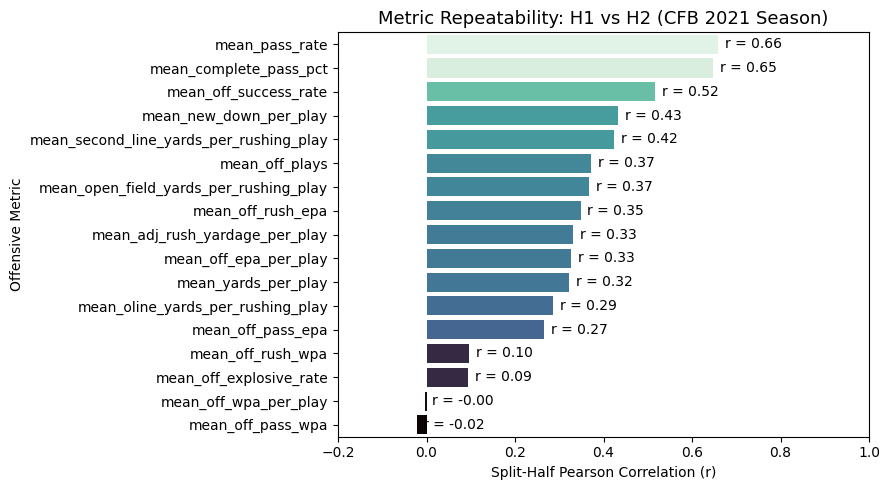

In [244]:
# Create a visualization of the results from the table above
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=correlation_results_2021,
    x='r',
    y='metric',
    palette='mako',
    hue='r',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"r = {width:.2f}",
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10
    )

plt.xlim(-0.2, 1.0)
plt.title("Metric Repeatability: H1 vs H2 (CFB 2021 Season)", fontsize=13)
plt.xlabel("Split-Half Pearson Correlation (r)")
plt.ylabel("Offensive Metric")
plt.tight_layout()
plt.show()

## 2022 table and visual:

In [245]:
# Create a formatted table using great_tables to display the correlation results
GT(correlation_results_2022).tab_header(
    title="2022 CFB Offense Split-Half Reliability",
    subtitle="Pearson Correlation (r) between Weeks 1-9 (H1) and Weeks 10-18 (H2)"
).cols_label(
    metric="Offensive Metric",
    r="Pearson r",
    p_value="p-value",
    r_squared="R²"
).fmt_number(
    columns=["r", "p_value", "r_squared"], 
    decimals=3
)

GT(_tbl_data=                                     metric         r       p_value  r_squared
1                     mean_off_epa_per_play  0.629680  8.801784e-09   0.396497
11                      mean_yards_per_play  0.617581  2.024882e-08   0.381406
7                     mean_off_success_rate  0.586957  1.435491e-07   0.344518
10                   mean_complete_pass_pct  0.546965  1.392760e-06   0.299171
9                            mean_pass_rate  0.540300  1.977844e-06   0.291924
2                         mean_off_pass_epa  0.459956  7.941849e-05   0.211560
8                   mean_off_explosive_rate  0.402547  6.661671e-04   0.162044
13                   mean_new_down_per_play  0.382922  1.268963e-03   0.146630
15  mean_second_line_yards_per_rushing_play  0.381283  1.336807e-03   0.145376
3                         mean_off_rush_epa  0.370104  1.893277e-03   0.136977
5                         mean_off_pass_wpa  0.356545  2.841520e-03   0.127124
0                            mean_off_plays  0.306781  1.094168e-02   0.094114
4                     mean_off_wpa_per_play  0.286125  1.801108e-02   0.081868
12           mean_adj_rush_yardage_per_play  0.283406  1.918406e-02   0.080319
16   mean_open_field_yards_per_rushing_play  0.225748  6.416636e-02   0.050962
14        mean_oline_yards_per_rushing_play  0.195511  1.100882e-01   0.038225
6                         mean_off_rush_wpa -0.045302  7.137438e-01   0.002052, _body=<great_tables._gt_data.Body object at 0x000001D57E536420>, _boxhead=Boxhead([ColInfo(var='metric', type=<ColInfoTypeEnum.default: 1>, column_label='Offensive Metric', column_align='left', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001D57E119FD0>, _spanners=Spanners([]), _heading=Heading(title='2022 CFB Offense Split-Half Reliability', subtitle='Pearson Correlation (r) between Weeks 1-9 (H1) and Weeks 10-18 (H2)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001D57E104260>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001D44076C260>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000001D57E1052B0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000001D56D1FD3D0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_colo

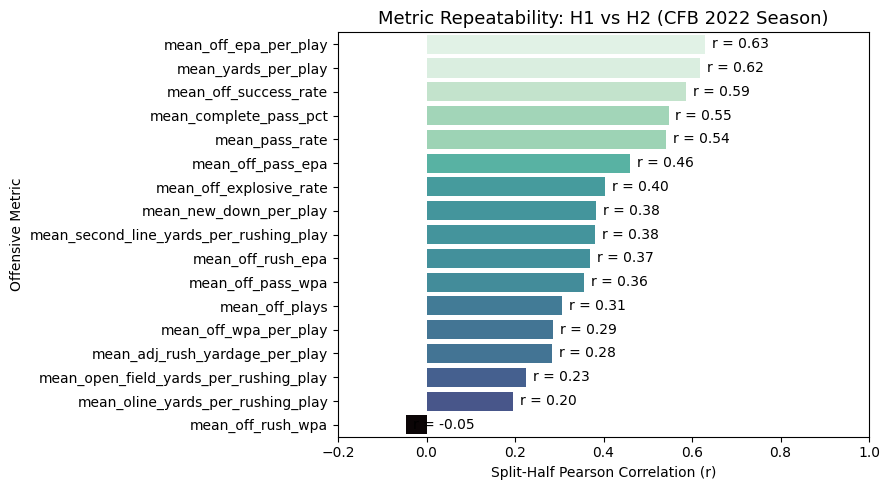

In [246]:
# Create a visualization of the results from the table above
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=correlation_results_2022,
    x='r',
    y='metric',
    palette='mako',
    hue='r',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"r = {width:.2f}",
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10
    )

plt.xlim(-0.2, 1.0)
plt.title("Metric Repeatability: H1 vs H2 (CFB 2022 Season)", fontsize=13)
plt.xlabel("Split-Half Pearson Correlation (r)")
plt.ylabel("Offensive Metric")
plt.tight_layout()
plt.show()

## 2023 table and visual:

In [247]:
# Create a formatted table using great_tables to display the correlation results
GT(correlation_results_2023).tab_header(
    title="2023 CFB Offense Split-Half Reliability",
    subtitle="Pearson Correlation (r) between Weeks 1-9 (H1) and Weeks 10-18 (H2)"
).cols_label(
    metric="Offensive Metric",
    r="Pearson r",
    p_value="p-value",
    r_squared="R²"
).fmt_number(
    columns=["r", "p_value", "r_squared"], 
    decimals=3
)

GT(_tbl_data=                                     metric         r       p_value  r_squared
10                   mean_complete_pass_pct  0.652650  1.632646e-09   0.425952
1                     mean_off_epa_per_play  0.615706  2.296684e-08   0.379094
9                            mean_pass_rate  0.597931  7.284457e-08   0.357521
7                     mean_off_success_rate  0.597441  7.512256e-08   0.356936
11                      mean_yards_per_play  0.563985  5.491516e-07   0.318079
2                         mean_off_pass_epa  0.530210  3.316043e-06   0.281123
13                   mean_new_down_per_play  0.436904  1.952658e-04   0.190885
6                         mean_off_rush_wpa  0.416423  4.122215e-04   0.173408
3                         mean_off_rush_epa  0.373982  1.680273e-03   0.139862
4                     mean_off_wpa_per_play  0.353998  3.060788e-03   0.125315
0                            mean_off_plays  0.344721  3.992660e-03   0.118832
14        mean_oline_yards_per_rushing_play  0.314442  9.014925e-03   0.098874
15  mean_second_line_yards_per_rushing_play  0.290209  1.636510e-02   0.084221
8                   mean_off_explosive_rate  0.284756  1.859368e-02   0.081086
12           mean_adj_rush_yardage_per_play  0.278954  2.124493e-02   0.077816
16   mean_open_field_yards_per_rushing_play  0.270099  2.590886e-02   0.072953
5                         mean_off_pass_wpa  0.229137  6.016658e-02   0.052504, _body=<great_tables._gt_data.Body object at 0x000001D5C2BD6600>, _boxhead=Boxhead([ColInfo(var='metric', type=<ColInfoTypeEnum.default: 1>, column_label='Offensive Metric', column_align='left', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001D57E0D0560>, _spanners=Spanners([]), _heading=Heading(title='2023 CFB Offense Split-Half Reliability', subtitle='Pearson Correlation (r) between Weeks 1-9 (H1) and Weeks 10-18 (H2)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001D43F369880>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001D57E11E2A0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000001D57E11E780>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000001D43F368E00>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_colo

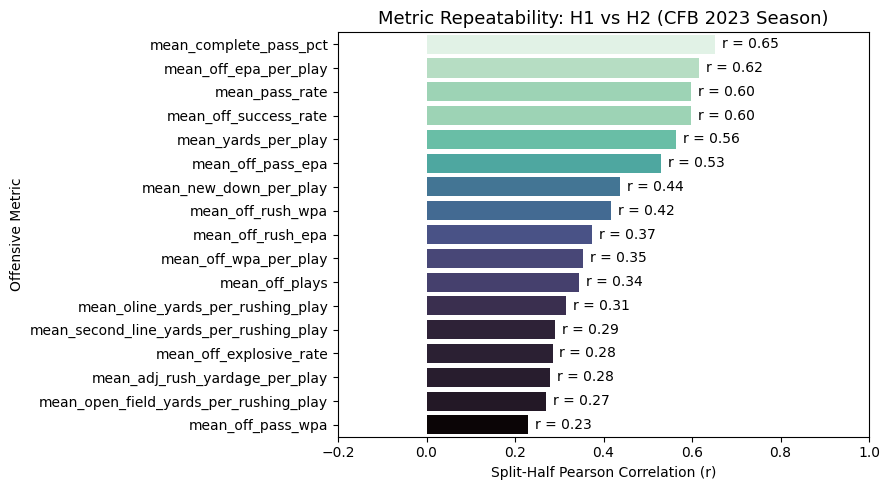

In [248]:
# Create a visualization of the results from the table above
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=correlation_results_2023,
    x='r',
    y='metric',
    palette='mako',
    hue='r',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"r = {width:.2f}",
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10
    )

plt.xlim(-0.2, 1.0)
plt.title("Metric Repeatability: H1 vs H2 (CFB 2023 Season)", fontsize=13)
plt.xlabel("Split-Half Pearson Correlation (r)")
plt.ylabel("Offensive Metric")
plt.tight_layout()
plt.show()

## 2024 table and visual:

In [249]:
# Create a formatted table using great_tables to display the correlation results
GT(correlation_results_2024).tab_header(
    title="2024 CFB Offense Split-Half Reliability",
    subtitle="Pearson Correlation (r) between Weeks 1-9 (H1) and Weeks 10-18 (H2)"
).cols_label(
    metric="Offensive Metric",
    r="Pearson r",
    p_value="p-value",
    r_squared="R²"
).fmt_number(
    columns=["r", "p_value", "r_squared"], 
    decimals=3
)

GT(_tbl_data=                                     metric         r       p_value  r_squared
10                   mean_complete_pass_pct  0.703345  2.261278e-11   0.494694
9                            mean_pass_rate  0.688169  8.913883e-11   0.473576
7                     mean_off_success_rate  0.532075  3.017697e-06   0.283104
1                     mean_off_epa_per_play  0.494642  1.806448e-05   0.244670
0                            mean_off_plays  0.482760  3.054843e-05   0.233057
11                      mean_yards_per_play  0.362923  2.352562e-03   0.131713
15  mean_second_line_yards_per_rushing_play  0.345905  3.861151e-03   0.119650
13                   mean_new_down_per_play  0.331758  5.713821e-03   0.110063
8                   mean_off_explosive_rate  0.274655  2.341158e-02   0.075435
12           mean_adj_rush_yardage_per_play  0.268097  2.707512e-02   0.071876
2                         mean_off_pass_epa  0.266839  2.783077e-02   0.071203
3                         mean_off_rush_epa  0.240667  4.804585e-02   0.057921
14        mean_oline_yards_per_rushing_play  0.235951  5.273653e-02   0.055673
16   mean_open_field_yards_per_rushing_play  0.227643  6.190391e-02   0.051821
4                     mean_off_wpa_per_play  0.143917  2.416491e-01   0.020712
6                         mean_off_rush_wpa  0.061612  6.176942e-01   0.003796
5                         mean_off_pass_wpa  0.033196  7.881278e-01   0.001102, _body=<great_tables._gt_data.Body object at 0x000001D57E104560>, _boxhead=Boxhead([ColInfo(var='metric', type=<ColInfoTypeEnum.default: 1>, column_label='Offensive Metric', column_align='left', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001D57E0EEA80>, _spanners=Spanners([]), _heading=Heading(title='2024 CFB Offense Split-Half Reliability', subtitle='Pearson Correlation (r) between Weeks 1-9 (H1) and Weeks 10-18 (H2)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001D57E536450>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001D572A1D670>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000001D572A1DBE0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000001D43F3A0500>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_colo

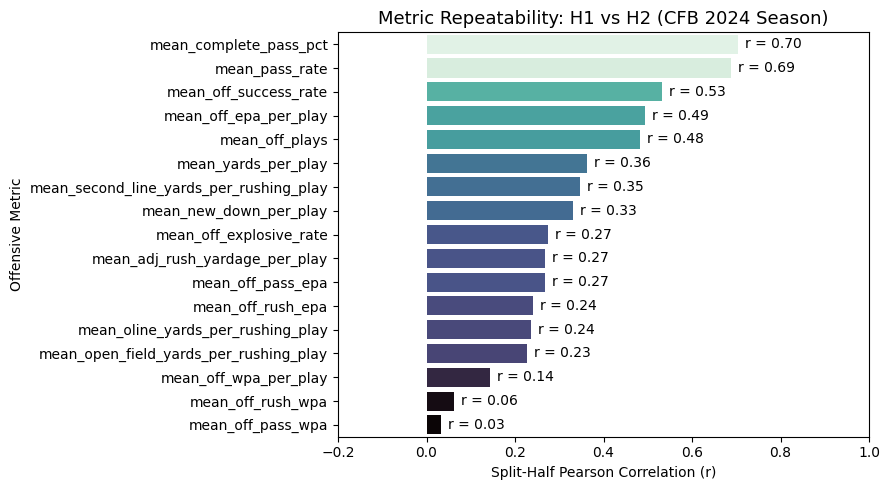

In [250]:
# Create a visualization of the results from the table above
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=correlation_results_2024,
    x='r',
    y='metric',
    palette='mako',
    hue='r',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"r = {width:.2f}",
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10
    )

plt.xlim(-0.2, 1.0)
plt.title("Metric Repeatability: H1 vs H2 (CFB 2024 Season)", fontsize=13)
plt.xlabel("Split-Half Pearson Correlation (r)")
plt.ylabel("Offensive Metric")
plt.tight_layout()
plt.show()

## 2025 table and visual:

In [251]:
# Create a formatted table using great_tables to display the correlation results
GT(correlation_results_2025).tab_header(
    title="2025 CFB Offense Split-Half Reliability",
    subtitle="Pearson Correlation (r) between Weeks 1-9 (H1) and Weeks 10-18 (H2)"
).cols_label(
    metric="Offensive Metric",
    r="Pearson r",
    p_value="p-value",
    r_squared="R²"
).fmt_number(
    columns=["r", "p_value", "r_squared"], 
    decimals=3
)

GT(_tbl_data=                                     metric         r       p_value  r_squared
17  mean_second_line_yards_per_rushing_play  0.606470  4.221000e-08   0.367805
7                     mean_off_success_rate  0.595500  8.483728e-08   0.354621
12           mean_adj_rush_yardage_per_play  0.592007  1.053827e-07   0.350473
16        mean_oline_yards_per_rushing_play  0.550206  1.171201e-06   0.302727
1                     mean_off_epa_per_play  0.510362  8.741828e-06   0.260470
11                      mean_yards_per_play  0.496743  1.642818e-05   0.246754
9                            mean_pass_rate  0.481984  3.159337e-05   0.232308
15                   mean_new_down_per_play  0.460462  7.781142e-05   0.212025
0                            mean_off_plays  0.444724  1.449422e-04   0.197780
3                         mean_off_rush_epa  0.389634  1.022476e-03   0.151815
10                   mean_complete_pass_pct  0.376873  1.535750e-03   0.142033
2                         mean_off_pass_epa  0.370149  1.890634e-03   0.137011
13          mean_air_yards_per_passing_play  0.358285  1.062432e-02   0.128368
18   mean_open_field_yards_per_rushing_play  0.297185  1.385127e-02   0.088319
8                   mean_off_explosive_rate  0.205148  9.330209e-02   0.042086
4                     mean_off_wpa_per_play  0.183006  1.352340e-01   0.033491
5                         mean_off_pass_wpa  0.096524  4.336075e-01   0.009317
6                         mean_off_rush_wpa  0.056148  6.492669e-01   0.003153
14  mean_yards_after_catch_per_passing_play  0.049793  7.313007e-01   0.002479, _body=<great_tables._gt_data.Body object at 0x000001D56D1A8B30>, _boxhead=Boxhead([ColInfo(var='metric', type=<ColInfoTypeEnum.default: 1>, column_label='Offensive Metric', column_align='left', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001D43F3DDF70>, _spanners=Spanners([]), _heading=Heading(title='2025 CFB Offense Split-Half Reliability', subtitle='Pearson Correlation (r) between Weeks 1-9 (H1) and Weeks 10-18 (H2)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001D56D2054F0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001D572A1E120>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000001D572A1C380>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000001D5755666C0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=Tr

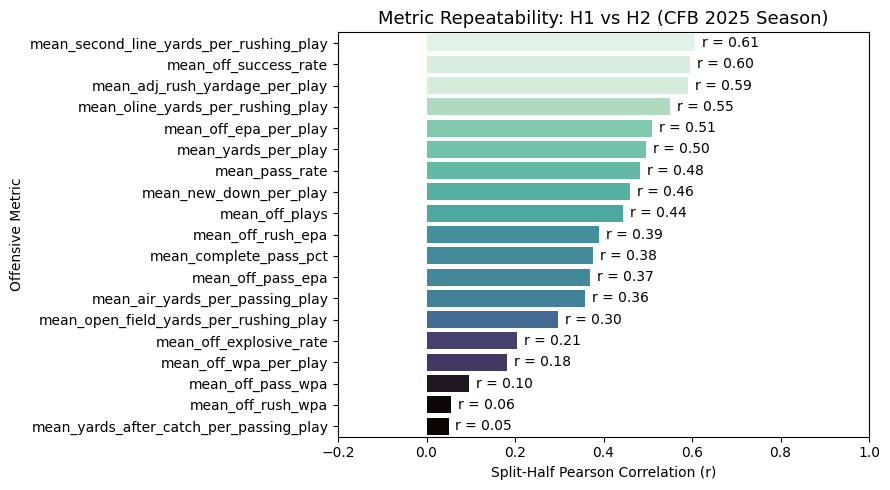

In [252]:
# Create a visualization of the results from the table above
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=correlation_results_2025,
    x='r',
    y='metric',
    palette='mako',
    hue='r',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"r = {width:.2f}",
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10
    )

plt.xlim(-0.2, 1.0)
plt.title("Metric Repeatability: H1 vs H2 (CFB 2025 Season)", fontsize=13)
plt.xlabel("Split-Half Pearson Correlation (r)")
plt.ylabel("Offensive Metric")
plt.tight_layout()
plt.show()

---

## **Homework Question:**

Find the three best **offensive**  metrics that you can for current P4 conference college football using data from the 2021 - 2025 regular seasons. Use a comparison that is the first part of the season to the second part of the season. Clearly state your conclusions about which metrics are **best** measures to use for predictive analytics about teams and describe the other metrics that you tried.

### **My answer/ conclusion:**

After calculating the overall best 3 offensive metrics in terms of useability/ reliability using half seasons as comparison, here are the 3 best offensive metrics:

- 'mean_off_success_rate' (which is based off of EPA)
- 'mean_pass_rate'
- 'mean_complete_pass_pct'

These metrics were chosen as they were not only the top 3 metrics in terms of r value from the combined 2021-2025 data, but also from the analyze(s) of each invidiual season. Although there were some mixed results among individual seasons, the 3 metrics that were listed above were the most consistent. In each individual season from 2021 - 2025, these 3 metrics were almost always listed top 5 in terms of r value and their p-values always indicated that they were statisitically distinguishable from 0 from one half of a season to the next. The only year where these metrics seemed to have had lower r values was the most recent season, 2025. Despite this, they still had significant p-values, indicating a non-zero relationship. 

These results from the individual seasons, along with the combined analysis, relay that these 3 offensive metrics are conssitent and reliabile throughout the entirety of the college football regular season from 2021-2025 (P4 teams only).